In [2]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [3]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [4]:
print(adata_age_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [5]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      151860
4–6      134748
7–10      91711
11–14    162356
15–18     55811
Name: count, dtype: int64

In [6]:
adata_age_cd4.obs["Age (years)"].value_counts().sort_index()

Age (years)
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [7]:
adata_age_cd4.obs["Sex"].value_counts().sort_index()

Sex
Female    274649
Male      321837
Name: count, dtype: int64

In [8]:
adata_age_cd4.obs["Age"].value_counts().sort_index()

Age
0     52475
1     20322
2     39325
3     39738
4     59464
5     27998
6     47286
7     34567
8     25099
9     18081
10    13964
11    47405
12    28930
13    37178
14    48843
15    23877
16    24326
17     7608
Name: count, dtype: int64

In [9]:
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [10]:
adata_age_cd4.obs['Batch'] = adata_age_cd4.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_age_cd4.obs["Age_group"] = pd.Categorical(
        adata_age_cd4.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )
"""
#centre age (compute difference between sex at different age)
adata_age_cd4.obs["Age_years"] = (
    adata_age_cd4.obs["Age (years)"]
    - adata_age_cd4.obs["Age (years)"].mean()
)
"""
adata_age_cd4.obs = adata_age_cd4.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_age_cd4.obs["Batch"] = adata_age_cd4.obs["Batch"].astype("category")
adata_age_cd4.obs["Age_years"] = adata_age_cd4.obs["Age_years"].astype("float")
adata_age_cd4.obs["Sex"] = adata_age_cd4.obs["Sex"].astype("category")
adata_age_cd4.obs["Age"] = adata_age_cd4.obs["Age"].astype("int")

In [11]:
adata_age_cd4.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [12]:
adata_age_cd4.obs["Batch"].value_counts().sort_index()

Batch
Batch01      9907
Batch02    109800
Batch03    111249
Batch04    128208
Batch05     69259
Batch06    102859
Batch07     65204
Name: count, dtype: int64

In [13]:
adata_age_cd4.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [14]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [15]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [16]:
""" Age group
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data
"""

' Age group\n# build sccoda input from cell-level data\ndef make_sccoda_from_lineage(\n    adata,\n    cell_type_col="cell_type",   \n    sample_col="pica_id",       \n    covariates=("Age_group","Child\'s sex"), \n):\n    sccoda_data = sccoda_model.load(\n        adata,\n        type="cell_level",\n        generate_sample_level=True,\n        cell_type_identifier=cell_type_col,\n        sample_identifier=sample_col,\n        covariate_obs=list(covariates),\n    )\n    return sccoda_data\n'

In [17]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch","Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [18]:
sccoda_cd4 = make_sccoda_from_lineage(adata_age_cd4, cell_type_col="pica_cell_type_complete_01_gdT_corrected")

In [19]:
sccoda_cd4

MuData object with n_obs × n_vars = 596614 × 38611
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 5
      obs:	'Age_years', 'pica_id', 'Batch', 'Sex', 'Age'
      var:	'n_cells'

## Age only model

In [20]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref,  # or e.g. "CD4_naive"
    )
    return sccoda_data

In [21]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


#### automatic ref cell type model (Treg)

In [35]:
cd4_auto = prepare_sccoda_age(sccoda_cd4.copy(), ref="automatic")

: 

In [ ]:
cd4_auto = run_sccoda(cd4_auto, rng_key=1)

sample: 100%|██████████| 7000/7000 [09:07<00:00, 12.78it/s, 511 steps of size 7.19e-03. acc. prob=0.77] 


In [ ]:
sccoda_model.summary(cd4_auto, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ Treg                                                                    │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 4                                                                       │
│ Spike-and-slab threshold              │ 0.876                                                                   │
│ Spike-and-slab threshold              │ 0.876                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 76.9%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.093        0.887   1.319  0.114      315.533                   │
│ CD4 cytoT                                     -0.626       -0.937  -0.244  0.187       56.558                   │
│ CD4 naive/Tcm                                  3.544        3.331   3.765  0.125     3660.161                   │
│ Tfh                                            0.922        0.688   1.164  0.125      265.938                   │
│ Treg                                           1.230        1.099   1.379  0.074      361.862                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000            361.862            0.000                                │
│ BatchT.Batch02      CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000            361.862            0.000                                │
│ BatchT.Batch03      CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000            361.862            0.000                                │
│ BatchT.Batch04      CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000            361.862            0.000                                │
│ BatchT.Batch05      CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000            361.862            0.000                                │
│ BatchT.Batch06      CD4 Tem            0.000            315.533            0.000                                │
│                     CD4 cytoT          0.000             56.558            0.000                                │
│                     CD4 naive/Tcm      0.000           3660.161            0.000                                │
│                     Tfh                0.000            265.938            0.000                                │
│                     Treg               0.000          

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem        -0.274  0.047   0.069         0.390                                          │
│                     CD4 cytoT      -0.363  0.283   0.108         0.417                                          │
│                     CD4 naive/Tcm  -0.121  0.181   0.050         0.360                                          │
│                     Tfh            -0.294  0.053   0.084         0.471                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch02      CD4 Tem        -0.108  0.145   0.041         0.357                                          │
│                     CD4 cytoT      -0.203  0.363   0.101         0.448                                          │
│                     CD4 naive/Tcm  -0.248  0.145   0.079         0.334                                          │
│                     Tfh            -0.156  0.156   0.046         0.329                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch03      CD4 Tem        -0.113  0.160   0.040         0.298                                          │
│                     CD4 cytoT      -0.254  0.236   0.082         0.417                                          │
│                     CD4 naive/Tcm  -0.266  0.114   0.086         0.338                                          │
│                     Tfh            -0.118  0.224   0.058         0.389                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch04      CD4 Tem        -0.178  0.094   0.039         0.300                                          │
│                     CD4 cytoT      -0.258  0.192   0.074         0.414                                          │
│                     CD4 naive/Tcm  -0.271  0.175   0.073         0.303                                          │
│                     Tfh            -0.128  0.173   0.047         0.331                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch05      CD4 Tem        -0.118  0.306   0.077         0.399                                          │
│                     CD4 cytoT      -0.131  0.548   0.154         0.507                                          │
│                     CD4 naive/Tcm  -0.390  0.005   0.140         0.824                                          │
│                     Tfh            -0.250  0.215   0.074         0.376                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch06      CD4 Tem        -0.118  0.167   0.043         0.313                                          │
│                     CD4 cytoT      -0.499  0.114   0.144         0.498                                          │
│                     CD4 naive/Tcm  -0.238  0.177   0.083         0.345                                          │
│                     Tfh            -0.148  0.164   0.048         0.331                                          │
│                     Treg            0.000  0.000   0.0

In [ ]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_auto, est_fdr=0.2, modality_key="coda")


In [ ]:
# check threshold
cd4_auto["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.507)

In [26]:
effects_cd4_auto = sccoda_model.get_effect_df(cd4_auto, modality_key="coda")

effects_cd4_auto["Inclusion probability"].max()
effects_cd4_auto["Inclusion probability"].describe()


count    45.000000
mean      0.331218
std       0.247003
min       0.000000
25%       0.198800
50%       0.337800
75%       0.414000
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_cd4_auto = sccoda_model.get_effect_df(cd4_auto, modality_key="coda")
effects_cd4_auto.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0  -0.274    0.047  0.069   
          CD4 cytoT                  0.0  -0.363    0.283  0.108   
          CD4 naive/Tcm              0.0  -0.121    0.181  0.050   
          Tfh                        0.0  -0.294    0.053  0.084   
          Treg                       0.0   0.000    0.000  0.000   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.3904       315.532708   
          CD4 cytoT                     0.4172        56.557756   
          CD4 naive/Tcm                 0.3596      3660.160753   
          Tfh                           0.4710       265.937773   
          Treg                          0.0000       361.861791   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

In [28]:
# counts per sample x celltype
counts = pd.DataFrame(
    cd4_auto["coda"].X,
    index=cd4_auto["coda"].obs_names,
    columns=cd4_auto["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = cd4_auto["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age"]])
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_years", "Age"],
        var_name="pica_cell_type_complete_01_gdT_corrected",
        value_name="Proportion",
    )
)

In [29]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['CD4 Tem', 'CD4 cytoT', 'CD4 naive/Tcm', 'Tfh', 'Treg'],
      dtype=object)

In [30]:
df["Age"].unique()

array([ 2, 15,  0,  1,  9,  3,  4,  5, 13,  6,  7, 10, 16, 12, 11, 14,  8,
       17])

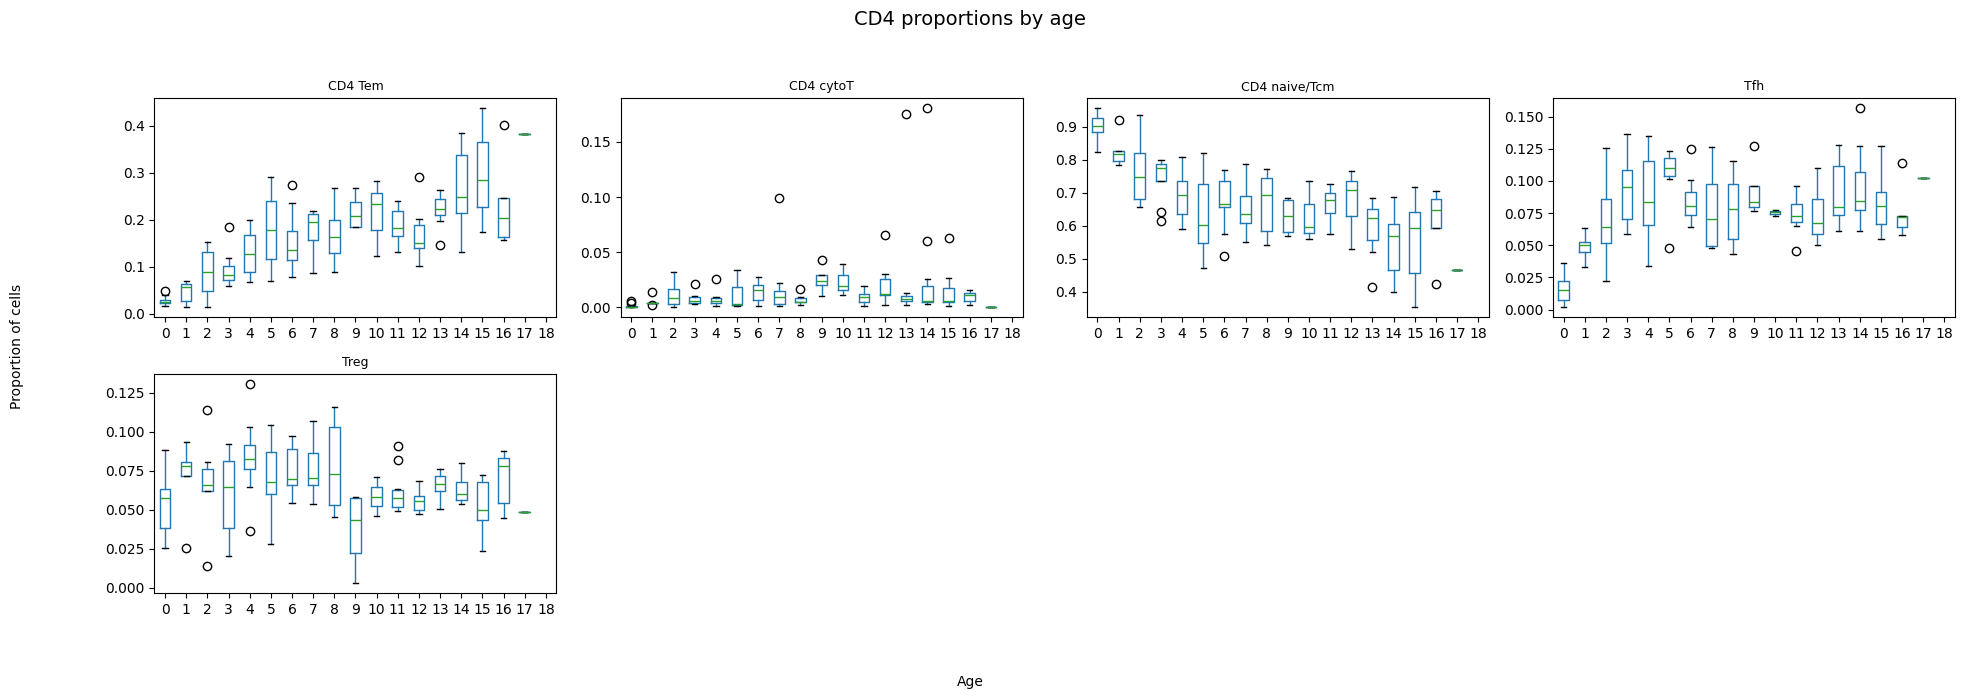

In [31]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(column="Proportion", by="Age", grid=False, ax=ax)

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("CD4 proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

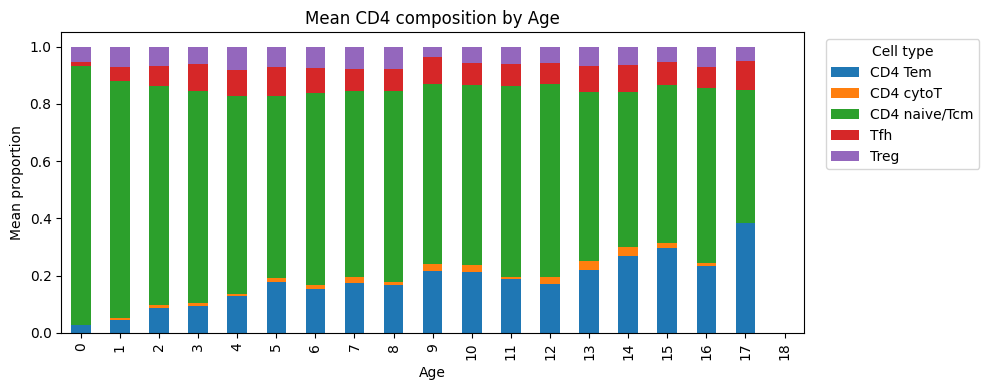

In [32]:
# barplot of composition by age group
props_age = (props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19)))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD4 composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

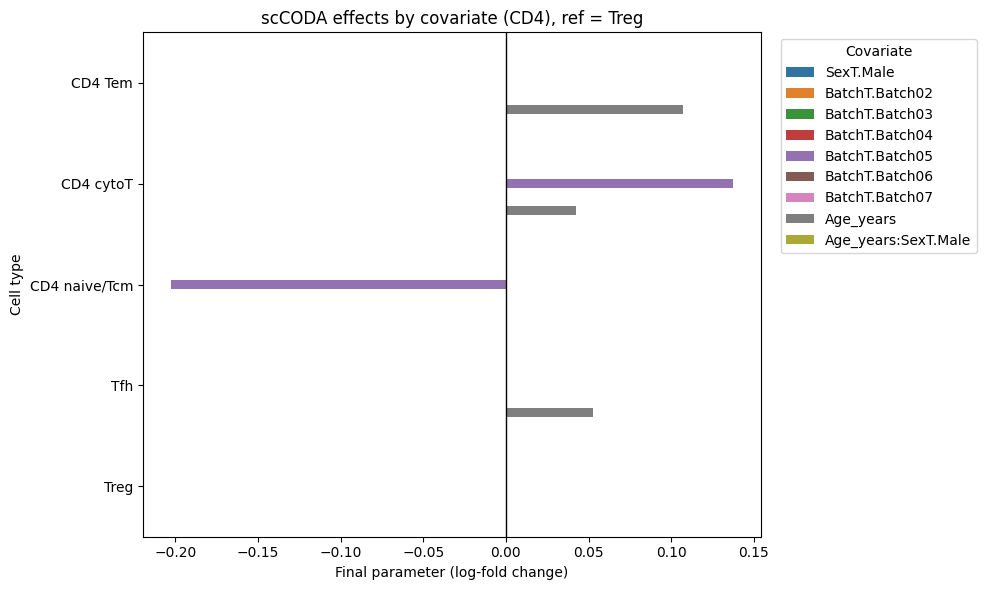

In [33]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_auto,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = Treg")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

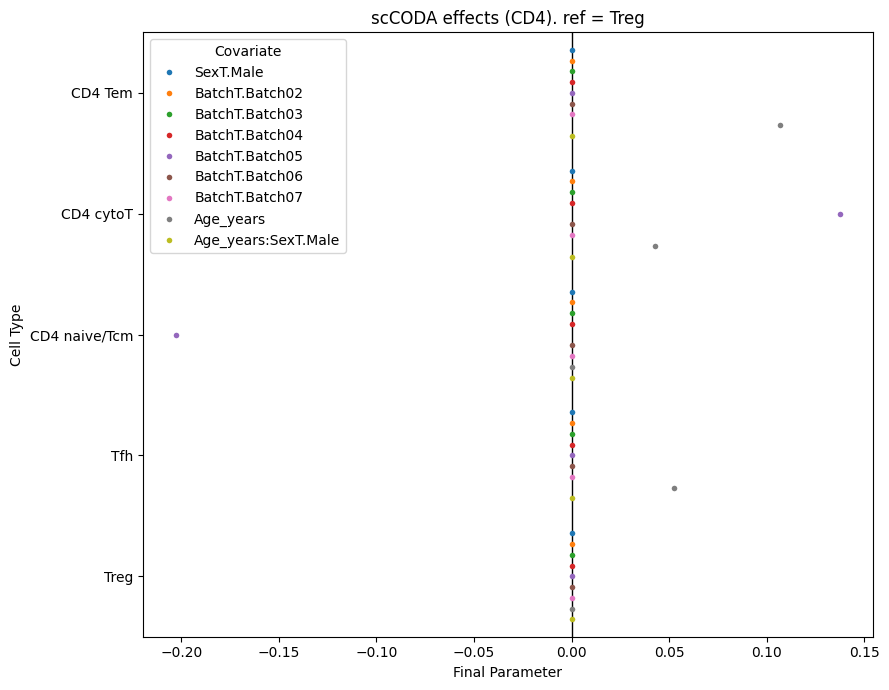

In [34]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_auto,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = Treg")
plt.tight_layout()
plt.show()

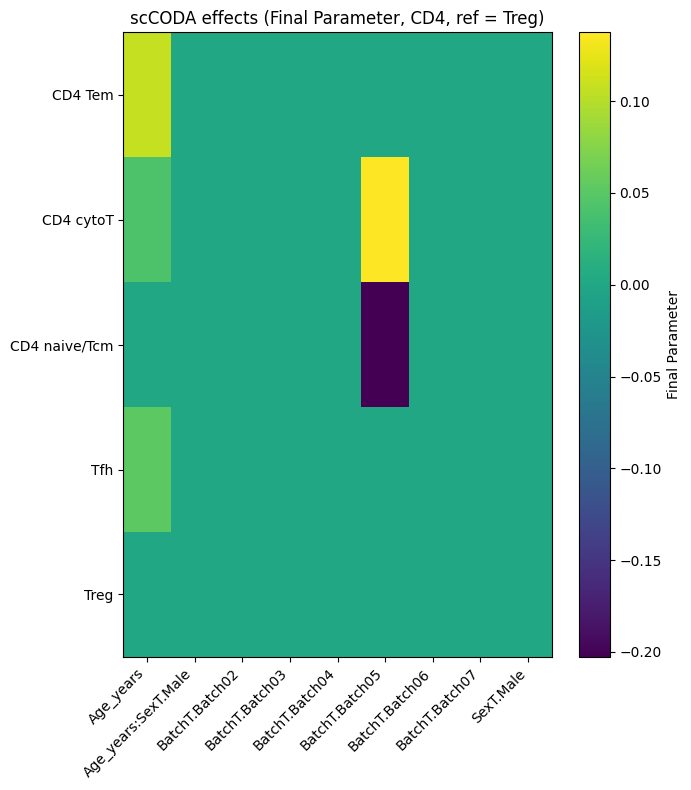

In [35]:
# inclusion pronbability heatmap
tmp_auto = effects_cd4_auto.reset_index()
ip_auto = tmp_auto.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_auto = effects_cd4_auto["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_auto.values, aspect="auto")
plt.yticks(range(beta_auto.shape[0]), beta_auto.index)
plt.xticks(range(beta_auto.shape[1]), beta_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = Treg)")
plt.tight_layout()
plt.show()

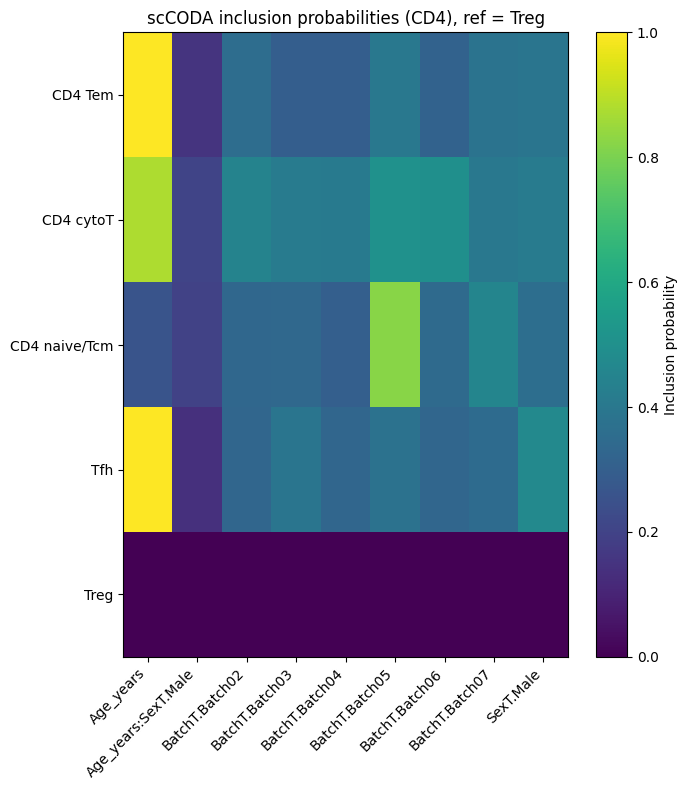

: 

In [ ]:
ip_auto = effects_cd4_auto["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_auto.values, aspect="auto")
plt.yticks(range(ip_auto.shape[0]), ip_auto.index)
plt.xticks(range(ip_auto.shape[1]), ip_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = Treg")
plt.tight_layout()
plt.show()


#### ref cell type model (CD4 naive/Tcm)

In [ ]:
cd4_naive = prepare_sccoda_age(sccoda_cd4.copy(), ref="CD4 naive/Tcm")

• Zero counts encountered in data! Added a pseudocount of 0.5.


: 

In [ ]:
cd4_naive = run_sccoda(cd4_naive, rng_key=2)

sample:  89%|████████▊ | 6200/7000 [09:36<01:16, 10.44it/s, 511 steps of size 6.03e-03. acc. prob=0.85] 

In [ ]:
sccoda_model.summary(cd4_naive, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ CD4 naive/Tcm                                                           │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 2                                                                       │
│ Spike-and-slab threshold              │ 0.896                                                                   │
│ Spike-and-slab threshold              │ 0.896                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 84.9%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.042        0.853   1.252  0.105      323.192                   │
│ CD4 cytoT                                     -0.645       -0.966  -0.288  0.179       59.814                   │
│ CD4 naive/Tcm                                  3.467        3.340   3.606  0.071     3652.787                   │
│ Tfh                                            0.871        0.656   1.083  0.115      272.393                   │
│ Treg                                           1.127        0.885   1.329  0.120      351.864                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000            351.864            0.000                                │
│ BatchT.Batch02      CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000            351.864            0.000                                │
│ BatchT.Batch03      CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000            351.864            0.000                                │
│ BatchT.Batch04      CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000            351.864            0.000                                │
│ BatchT.Batch05      CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000            351.864            0.000                                │
│ BatchT.Batch06      CD4 Tem            0.000            323.192            0.000                                │
│                     CD4 cytoT          0.000             59.814            0.000                                │
│                     CD4 naive/Tcm      0.000           3652.787            0.000                                │
│                     Tfh                0.000            272.393            0.000                                │
│                     Treg               0.000          

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem        -0.181  0.051   0.047         0.360                                          │
│                     CD4 cytoT      -0.339  0.305   0.103         0.369                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.237  0.060   0.064         0.414                                          │
│                     Treg           -0.136  0.154   0.045         0.327                                          │
│ BatchT.Batch02      CD4 Tem        -0.101  0.156   0.035         0.292                                          │
│                     CD4 cytoT      -0.170  0.355   0.095         0.391                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.196  0.113   0.051         0.347                                          │
│                     Treg           -0.262  0.123   0.068         0.360                                          │
│ BatchT.Batch03      CD4 Tem        -0.090  0.164   0.039         0.311                                          │
│                     CD4 cytoT      -0.252  0.247   0.077         0.386                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.095  0.207   0.053         0.364                                          │
│                     Treg           -0.066  0.305   0.078         0.406                                          │
│ BatchT.Batch04      CD4 Tem        -0.171  0.087   0.044         0.347                                          │
│                     CD4 cytoT      -0.257  0.197   0.075         0.371                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.139  0.164   0.046         0.336                                          │
│                     Treg           -0.159  0.148   0.048         0.336                                          │
│ BatchT.Batch05      CD4 Tem        -0.035  0.306   0.098         0.550                                          │
│                     CD4 cytoT      -0.113  0.595   0.172         0.525                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.117  0.289   0.073         0.372                                          │
│                     Treg           -0.081  0.402   0.117         0.490                                          │
│ BatchT.Batch06      CD4 Tem        -0.095  0.171   0.042         0.293                                          │
│                     CD4 cytoT      -0.531  0.099   0.149         0.480                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.163  0.182   0.052         0.327                                          │
│                     Treg           -0.060  0.387   0.1

In [ ]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_naive, est_fdr=0.2, modality_key="coda")


In [ ]:
# check threshold
cd4_naive["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.55)

In [ ]:
effects_cd4_naive = sccoda_model.get_effect_df(cd4_naive, modality_key="coda")

effects_cd4_naive["Inclusion probability"].max()
effects_cd4_naive["Inclusion probability"].describe()


count    45.000000
mean      0.329231
std       0.239836
min       0.000000
25%       0.223400
50%       0.347200
75%       0.402800
max       1.000000
Name: Inclusion probability, dtype: float64

In [ ]:

# effects dataframe
effects_cd4_naive = sccoda_model.get_effect_df(cd4_naive, modality_key="coda")
effects_cd4_naive.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0  -0.181    0.051  0.047   
          CD4 cytoT                  0.0  -0.339    0.305  0.103   
          CD4 naive/Tcm              0.0   0.000    0.000  0.000   
          Tfh                        0.0  -0.237    0.060  0.064   
          Treg                       0.0  -0.136    0.154  0.045   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.3602       323.191751   
          CD4 cytoT                     0.3686        59.814362   
          CD4 naive/Tcm                 0.0000      3652.787314   
          Tfh                           0.4136       272.392980   
          Treg                          0.3272       351.864375   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

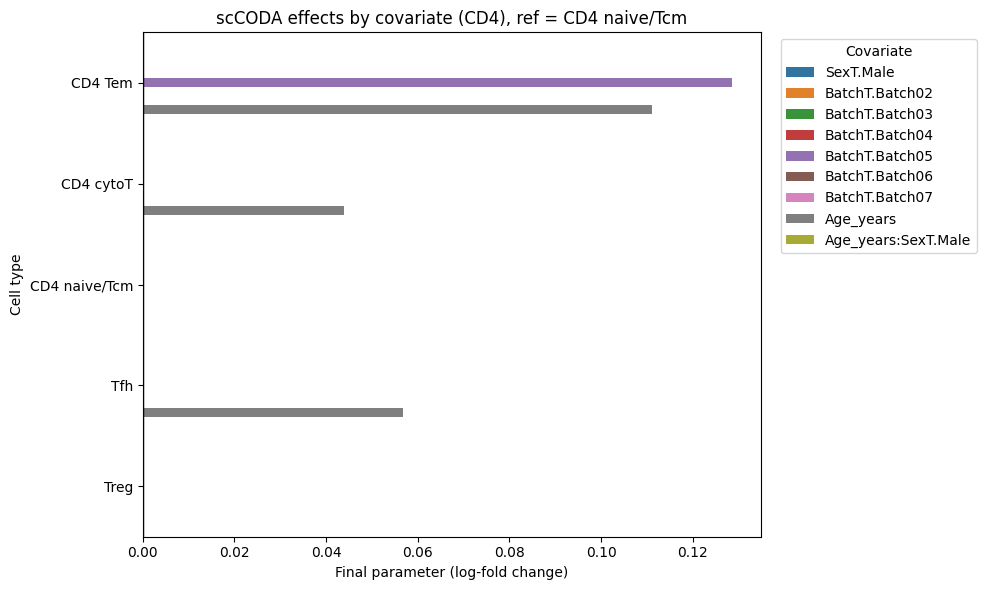

In [ ]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_naive,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = CD4 naive/Tcm")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

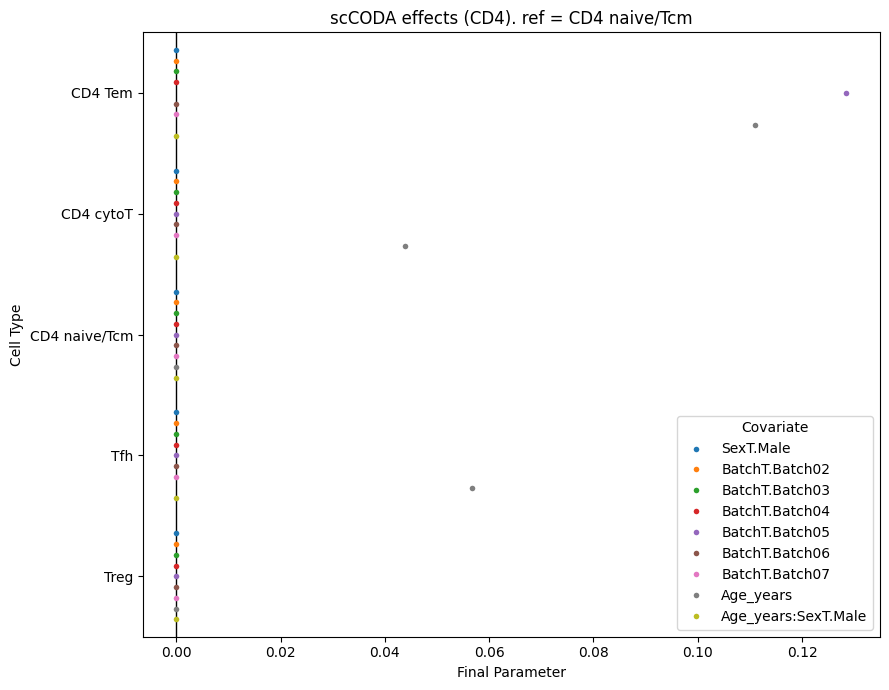

In [ ]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_naive,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = CD4 naive/Tcm")
plt.tight_layout()
plt.show()

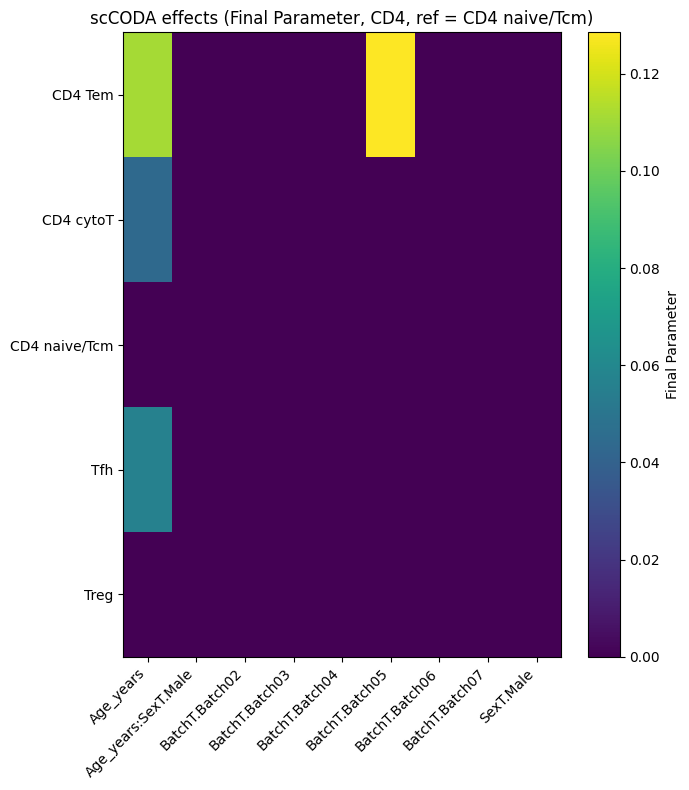

In [ ]:
# inclusion pronbability heatmap
tmp_naive = effects_cd4_naive.reset_index()
ip_naive = tmp_naive.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_naive = effects_cd4_naive["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_naive.values, aspect="auto")
plt.yticks(range(beta_naive.shape[0]), beta_naive.index)
plt.xticks(range(beta_naive.shape[1]), beta_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = CD4 naive/Tcm)")
plt.tight_layout()
plt.show()

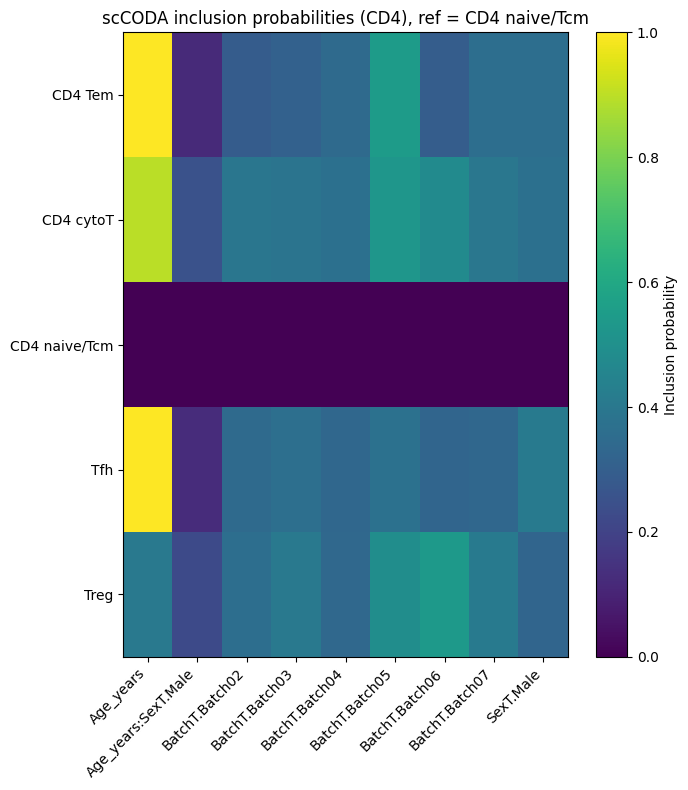

: 

In [ ]:
ip_naive = effects_cd4_naive["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_naive.values, aspect="auto")
plt.yticks(range(ip_naive.shape[0]), ip_naive.index)
plt.xticks(range(ip_naive.shape[1]), ip_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = CD4 naive/Tcm")
plt.tight_layout()
plt.show()


#### automatic ref cell type model (CD4 Tem)

In [22]:
cd4_tem = prepare_sccoda_age(sccoda_cd4.copy(), ref="CD4 Tem")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [23]:
cd4_tem  = run_sccoda(cd4_tem , rng_key=3)

sample: 100%|██████████| 7000/7000 [15:32<00:00,  7.51it/s, 1023 steps of size 3.00e-03. acc. prob=0.98]


! Acceptance rate unusually high (0.9768560804607238 > 0.95)! Results might be incorrect! Please check feasibility of results and re-run the sampling step with a different rng_key if necessary.


In [24]:
sccoda_model.summary(cd4_tem , modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ CD4 Tem                                                                 │
│ Formula                               │ Age_years * Sex + Batch                                                 │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 97.7%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.814        1.667   1.963  0.078      313.930                   │
│ CD4 cytoT                                     -0.386       -0.595  -0.174  0.113       34.784                   │
│ CD4 naive/Tcm                                  4.325        3.964   4.954  0.279     3866.758                   │
│ Tfh                                            1.292        1.068   1.564  0.136      186.265                   │
│ Treg                                           1.619        1.345   1.859  0.137      258.313                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000           258.313            0.000                                │
│ BatchT.Batch02      CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000           258.313            0.000                                │
│ BatchT.Batch03      CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000           258.313            0.000                                │
│ BatchT.Batch04      CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000           258.313            0.000                                │
│ BatchT.Batch05      CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000           258.313            0.000                                │
│ BatchT.Batch06      CD4 Tem             0.000           313.930            0.000                                │
│                     CD4 cytoT           0.000            34.784            0.000                                │
│                     CD4 naive/Tcm       0.000          3866.758            0.000                                │
│                     Tfh                 0.000           186.265            0.000                                │
│                     Treg                0.000         

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.235   0.167  0.064         0.368                                          │
│                     CD4 naive/Tcm  -0.071   0.179  0.044         0.324                                          │
│                     Tfh            -0.256   0.060  0.064         0.404                                          │
│                     Treg           -0.140   0.165  0.044         0.313                                          │
│ BatchT.Batch02      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.182   0.342  0.091         0.388                                          │
│                     CD4 naive/Tcm  -0.809   0.070  0.262         0.523                                          │
│                     Tfh            -0.291   0.119  0.073         0.356                                          │
│                     Treg           -0.401   0.103  0.116         0.455                                          │
│ BatchT.Batch03      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.311   0.262  0.088         0.354                                          │
│                     CD4 naive/Tcm  -0.810   0.061  0.250         0.455                                          │
│                     Tfh            -0.113   0.297  0.080         0.376                                          │
│                     Treg           -0.064   0.413  0.129         0.501                                          │
│ BatchT.Batch04      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.289   0.225  0.080         0.379                                          │
│                     CD4 naive/Tcm  -0.718   0.134  0.229         0.462                                          │
│                     Tfh            -0.150   0.205  0.056         0.336                                          │
│                     Treg           -0.131   0.293  0.073         0.362                                          │
│ BatchT.Batch05      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.234   0.513  0.149         0.441                                          │
│                     CD4 naive/Tcm  -0.913   0.014  0.290         0.839                                          │
│                     Tfh            -0.234   0.250  0.074         0.325                                          │
│                     Treg           -0.157   0.385  0.097         0.367                                          │
│ BatchT.Batch06      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.485   0.141  0.130         0.410                                          │
│                     CD4 naive/Tcm  -0.788   0.078  0.247         0.470                                          │
│                     Tfh            -0.146   0.237  0.063         0.331                                          │
│                     Treg           -0.055   0.455  0.1

In [25]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_tem , est_fdr=0.2, modality_key="coda")


In [26]:
# check threshold
cd4_tem ["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.564)

In [27]:
effects_cd4_tem= sccoda_model.get_effect_df(cd4_tem, modality_key="coda")

effects_cd4_tem["Inclusion probability"].max()
effects_cd4_tem["Inclusion probability"].describe()


count    45.000000
mean      0.334662
std       0.245708
min       0.000000
25%       0.130800
50%       0.361800
75%       0.454800
max       1.000000
Name: Inclusion probability, dtype: float64

In [28]:

# effects dataframe
effects_cd4_tem = sccoda_model.get_effect_df(cd4_tem, modality_key="coda")
effects_cd4_tem.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0   0.000    0.000  0.000   
          CD4 cytoT                  0.0  -0.235    0.167  0.064   
          CD4 naive/Tcm              0.0  -0.071    0.179  0.044   
          Tfh                        0.0  -0.256    0.060  0.064   
          Treg                       0.0  -0.140    0.165  0.044   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.0000       313.930500   
          CD4 cytoT                     0.3680        34.784491   
          CD4 naive/Tcm                 0.3238      3866.757666   
          Tfh                           0.4044       186.265229   
          Treg                          0.3130       258.312895   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

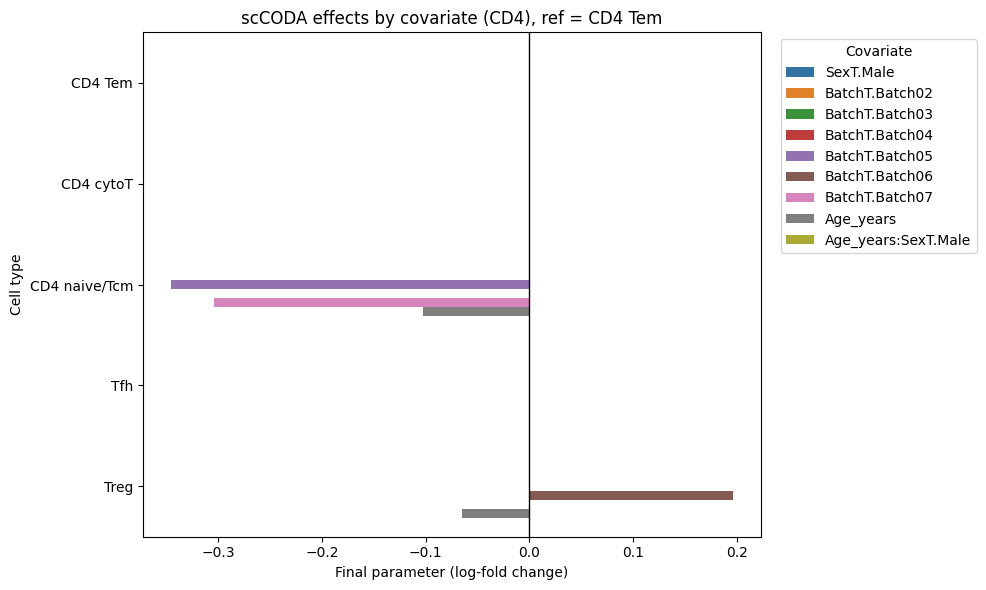

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_tem,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = CD4 Tem")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

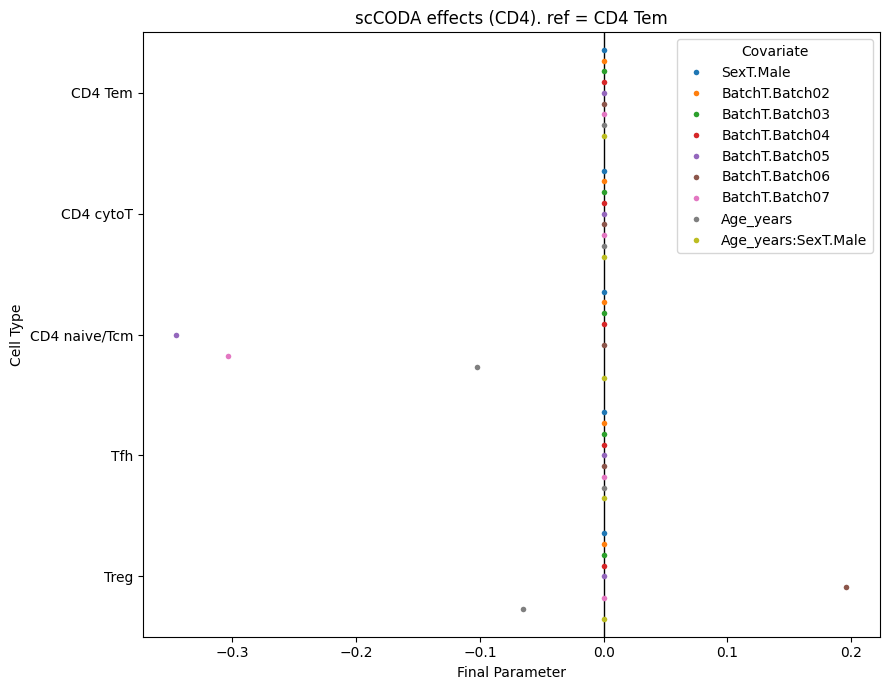

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_tem,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = CD4 Tem")
plt.tight_layout()
plt.show()

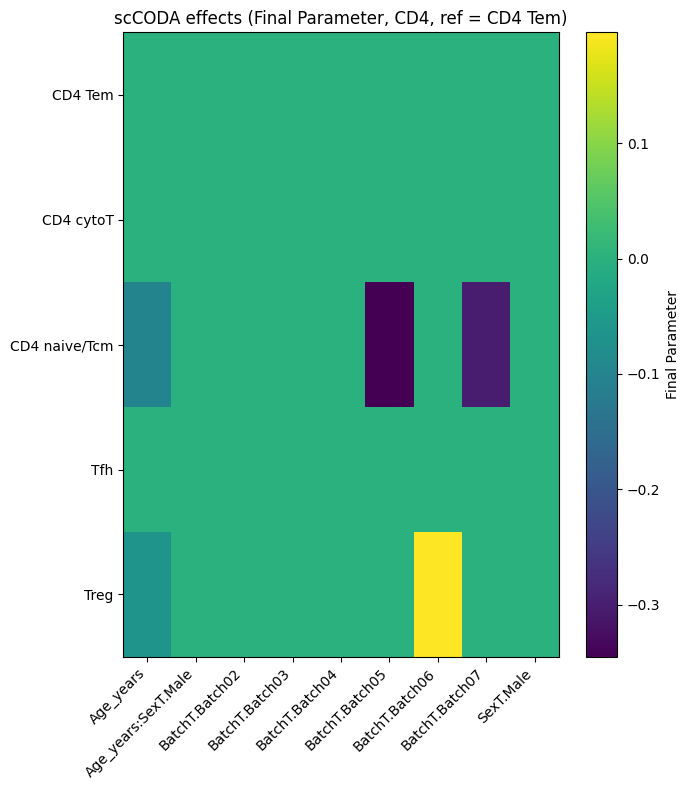

In [31]:
# inclusion pronbability heatmap
tmp_tem = effects_cd4_tem.reset_index()
ip_tem = tmp_tem.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_tem = effects_cd4_tem["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_tem.values, aspect="auto")
plt.yticks(range(beta_tem.shape[0]), beta_tem.index)
plt.xticks(range(beta_tem.shape[1]), beta_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = CD4 Tem)")
plt.tight_layout()
plt.show()

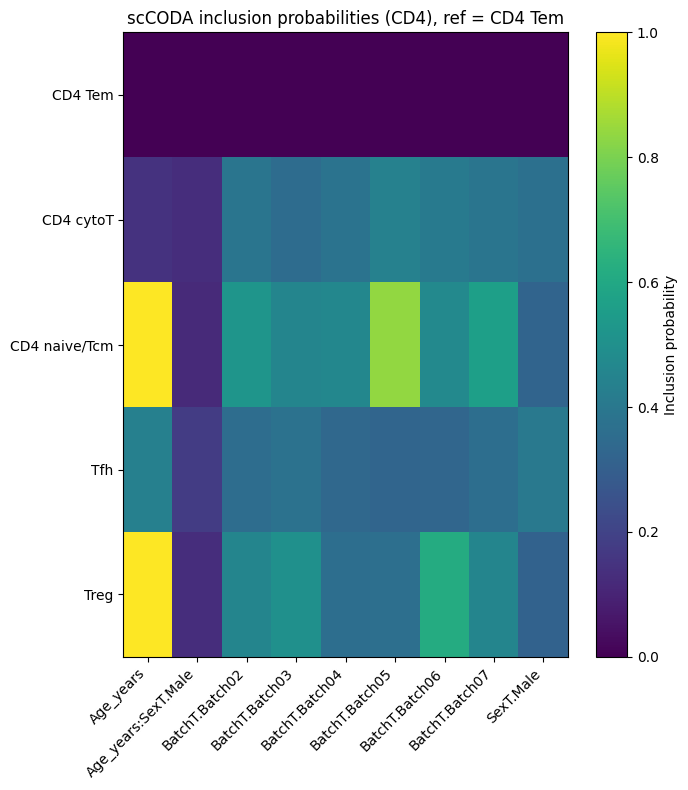

In [32]:
ip_tem = effects_cd4_tem["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_tem.values, aspect="auto")
plt.yticks(range(ip_tem.shape[0]), ip_tem.index)
plt.xticks(range(ip_tem.shape[1]), ip_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = CD4 Tem")
plt.tight_layout()
plt.show()
